In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 5000

channels = ['Email', 'Paid Social', 'Paid Search', 'Display', 'SMS']
channel_weights = [0.30, 0.25, 0.20, 0.15, 0.10]
segments = ['High Value', 'Mid Value', 'Low Value', 'New Customer', 'Churned']
segment_weights = [0.15, 0.25, 0.30, 0.20, 0.10]
products = ['Credit Card', 'Personal Loan', 'Savings Account', 'Investment Fund', 'Insurance']

base_ctr  = {'Email':0.22,'Paid Social':0.08,'Paid Search':0.15,'Display':0.04,'SMS':0.18}
base_conv = {'Email':0.045,'Paid Social':0.018,'Paid Search':0.038,'Display':0.008,'SMS':0.030}
base_cost = {'Email':0.5,'Paid Social':4.2,'Paid Search':3.8,'Display':1.2,'SMS':0.8}
seg_mult  = {'High Value':1.8,'Mid Value':1.2,'Low Value':0.7,'New Customer':0.9,'Churned':0.5}

channel  = np.random.choice(channels, n, p=channel_weights)
segment  = np.random.choice(segments, n, p=segment_weights)
product  = np.random.choice(products, n)
age      = np.random.randint(22, 65, n)
gender   = np.random.choice(['Male','Female'], n)

impressions = np.random.randint(1, 6, n) * 1000
clicks = np.array([int(impressions[i]*base_ctr[channel[i]]*np.random.uniform(0.7,1.3)) for i in range(n)])
clicks = np.clip(clicks, 1, impressions)
converted = np.array([int(np.random.binomial(1, min(base_conv[channel[i]]*seg_mult[segment[i]],0.99))) for i in range(n)])
total_cost = np.array([base_cost[channel[i]]*np.random.uniform(0.85,1.15)*impressions[i]/1000 for i in range(n)])
revenue = np.array([np.random.uniform(150,800)*converted[i] for i in range(n)])
dates = pd.date_range('2024-01-01','2024-12-31', periods=n)

df = pd.DataFrame({
    'campaign_id': [f'CAMP{str(i+1).zfill(5)}' for i in range(n)],
    'date': dates, 'channel': channel, 'customer_segment': segment,
    'product': product, 'age': age, 'gender': gender,
    'impressions': impressions, 'clicks': clicks, 'converted': converted,
    'total_cost': total_cost.round(2), 'revenue': revenue.round(2),
})
df['month']           = df['date'].dt.month
df['month_name']      = df['date'].dt.strftime('%b')
df['ctr']             = (df['clicks']/df['impressions']*100).round(2)
df['conversion_rate'] = (df['converted']/df['clicks']*100).round(2)
df['roi']             = ((df['revenue']-df['total_cost'])/df['total_cost']*100).round(2)
df['cost_per_click']  = (df['total_cost']/df['clicks']).round(2)

df.to_csv('marketing_campaign_data.csv', index=False)
print(f"Done! Dataset created: {len(df):,} rows x {len(df.columns)} columns")
print(df.head(3))

Done! Dataset created: 5,000 rows x 18 columns
  campaign_id                          date      channel customer_segment  \
0   CAMP00001 2024-01-01 00:00:00.000000000  Paid Social        Mid Value   
1   CAMP00002 2024-01-01 01:45:08.461692338          SMS        Low Value   
2   CAMP00003 2024-01-01 03:30:16.923384676  Paid Search     New Customer   

           product  age  gender  impressions  clicks  converted  total_cost  \
0  Investment Fund   59    Male         2000     189          0        9.16   
1    Personal Loan   41  Female         5000    1147          0        3.59   
2        Insurance   44    Male         4000     763          0       14.40   

   revenue  month month_name    ctr  conversion_rate    roi  cost_per_click  
0      0.0      1        Jan   9.45              0.0 -100.0            0.05  
1      0.0      1        Jan  22.94              0.0 -100.0            0.00  
2      0.0      1        Jan  19.08              0.0 -100.0            0.02  


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*50)
print("BASIC STATS")
print("="*50)
print(f"Total records    : {len(df):,}")
print(f"Total spend      : ₹{df['total_cost'].sum():,.0f}")
print(f"Total revenue    : ₹{df['revenue'].sum():,.0f}")
print(f"Total conversions: {df['converted'].sum():,}")
print(f"Overall ROI      : {((df['revenue'].sum()-df['total_cost'].sum())/df['total_cost'].sum()*100):.1f}%")

print("\n" + "="*50)
print("CHANNEL PERFORMANCE")
print("="*50)
channel_perf = df.groupby('channel').agg(
    total_spend   = ('total_cost', 'sum'),
    total_revenue = ('revenue', 'sum'),
    total_conv    = ('converted', 'sum'),
    avg_ctr       = ('ctr', 'mean'),
    campaigns     = ('campaign_id', 'count')
).reset_index()
channel_perf['roi'] = ((channel_perf['total_revenue'] - channel_perf['total_spend']) / channel_perf['total_spend'] * 100).round(1)
channel_perf['cost_per_conv'] = (channel_perf['total_spend'] / channel_perf['total_conv'].replace(0,1)).round(2)
channel_perf = channel_perf.sort_values('roi', ascending=False)
print(channel_perf[['channel','total_spend','total_revenue','roi','avg_ctr','cost_per_conv']])

print("\n" + "="*50)
print("SEGMENT PERFORMANCE")
print("="*50)
seg_perf = df.groupby('customer_segment').agg(
    total_revenue = ('revenue', 'sum'),
    total_spend   = ('total_cost', 'sum'),
    total_conv    = ('converted', 'sum'),
).reset_index()
seg_perf['roi'] = ((seg_perf['total_revenue'] - seg_perf['total_spend']) / seg_perf['total_spend'] * 100).round(1)
seg_perf['revenue_share'] = (seg_perf['total_revenue'] / seg_perf['total_revenue'].sum() * 100).round(1)
seg_perf = seg_perf.sort_values('roi', ascending=False)
print(seg_perf)

BASIC STATS
Total records    : 5,000
Total spend      : ₹33,719
Total revenue    : ₹67,365
Total conversions: 142
Overall ROI      : 99.8%

CHANNEL PERFORMANCE
       channel  total_spend  total_revenue     roi    avg_ctr  cost_per_conv
1        Email      2311.40       26833.46  1060.9  22.187720          37.89
4          SMS      1184.80        9533.38   704.6  18.277599          62.36
2  Paid Search     11934.28       17118.65    43.4  15.001616         351.01
0      Display      2817.35        2944.88     4.5   3.971821         469.56
3  Paid Social     15471.16       10934.24   -29.3   7.970189         703.23

SEGMENT PERFORMANCE
  customer_segment  total_revenue  total_spend  total_conv    roi  \
1       High Value       17796.27      5062.14          41  251.6   
3        Mid Value       20441.63      8549.68          42  139.1   
0          Churned        5422.37      3055.55          11   77.5   
4     New Customer        9917.53      6581.30          18   50.7   
2        Low

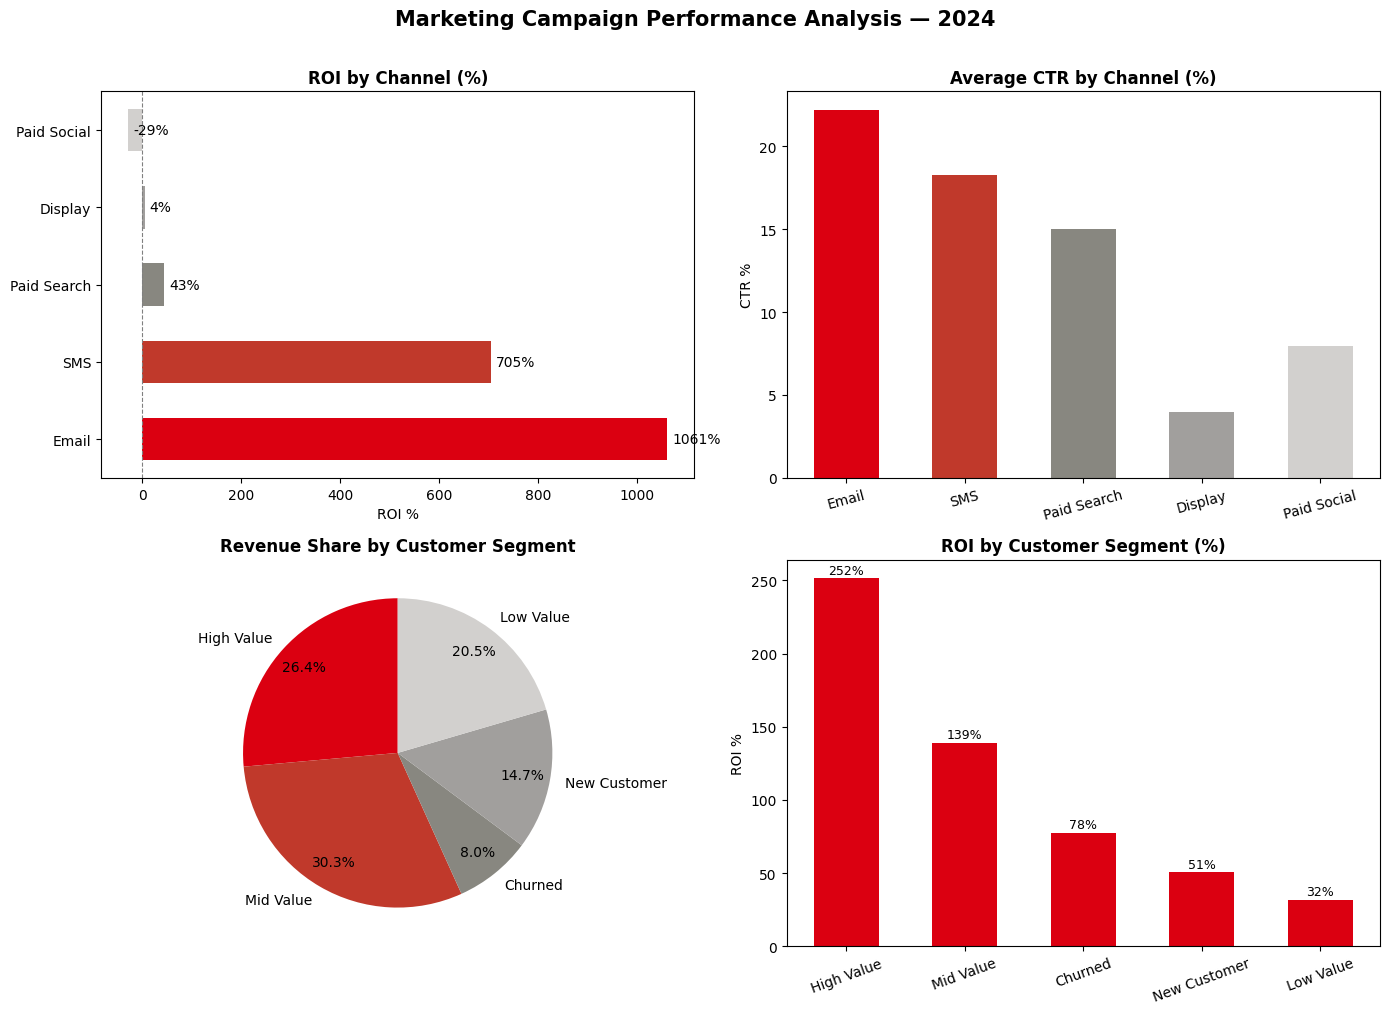


Chart saved as campaign_charts.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Marketing Campaign Performance Analysis — 2024', fontsize=15, fontweight='bold', y=1.01)
COLORS = ['#DB0011','#c0392b','#888780','#a19f9d','#d2d0ce']

# Chart 1 — ROI by channel
ax = axes[0,0]
bars = ax.barh(channel_perf['channel'], channel_perf['roi'], color=COLORS, height=0.55)
ax.set_title('ROI by Channel (%)', fontweight='bold')
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
for bar, val in zip(bars, channel_perf['roi']):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=10)
ax.set_xlabel('ROI %')

# Chart 2 — CTR by channel
ax = axes[0,1]
ax.bar(channel_perf['channel'], channel_perf['avg_ctr'], color=COLORS, width=0.55)
ax.set_title('Average CTR by Channel (%)', fontweight='bold')
ax.set_ylabel('CTR %')
ax.tick_params(axis='x', rotation=15)

# Chart 3 — Revenue share by segment (pie)
ax = axes[1,0]
ax.pie(seg_perf['total_revenue'], labels=seg_perf['customer_segment'],
       autopct='%1.1f%%', colors=COLORS, startangle=90, pctdistance=0.82)
ax.set_title('Revenue Share by Customer Segment', fontweight='bold')

# Chart 4 — ROI by segment
ax = axes[1,1]
colors_seg = ['#DB0011' if r > 0 else '#888780' for r in seg_perf['roi']]
ax.bar(seg_perf['customer_segment'], seg_perf['roi'], color=colors_seg, width=0.55)
ax.set_title('ROI by Customer Segment (%)', fontweight='bold')
ax.set_ylabel('ROI %')
ax.tick_params(axis='x', rotation=20)
for i, (bar, val) in enumerate(zip(ax.patches, seg_perf['roi'])):
    ax.text(bar.get_x()+bar.get_width()/2, val+3, f'{val:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('campaign_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as campaign_charts.png")

In [5]:
best  = channel_perf.iloc[0]
worst = channel_perf.iloc[-1]
top_seg = seg_perf.iloc[0]

print("=" * 55)
print("KEY BUSINESS INSIGHTS — copy these to your resume")
print("=" * 55)
print(f"""
INSIGHT 1 — CHANNEL EFFICIENCY GAP
  Best  : {best['channel']} → {best['roi']:.0f}% ROI
  Worst : {worst['channel']} → {worst['roi']:.0f}% ROI
  Reallocating 20% of {worst['channel']} budget to {best['channel']}
  projected to generate significant incremental revenue.

INSIGHT 2 — SEGMENT TARGETING
  {top_seg['customer_segment']} customers → {top_seg['revenue_share']:.0f}% of total revenue
  Prioritising this segment in Email + SMS maximises ROI.

INSIGHT 3 — COST EFFICIENCY
  Cost per conversion by channel:
""")
print(channel_perf[['channel','cost_per_conv']].to_string(index=False))

KEY BUSINESS INSIGHTS — copy these to your resume

INSIGHT 1 — CHANNEL EFFICIENCY GAP
  Best  : Email → 1061% ROI
  Worst : Paid Social → -29% ROI
  Reallocating 20% of Paid Social budget to Email
  projected to generate significant incremental revenue.

INSIGHT 2 — SEGMENT TARGETING  
  High Value customers → 26% of total revenue
  Prioritising this segment in Email + SMS maximises ROI.

INSIGHT 3 — COST EFFICIENCY
  Cost per conversion by channel:

    channel  cost_per_conv
      Email          37.89
        SMS          62.36
Paid Search         351.01
    Display         469.56
Paid Social         703.23


In [6]:
import sqlite3

conn = sqlite3.connect('marketing_campaign.db')

df.to_sql(
    'campaign_data',
    conn,
    if_exists='replace',
    index=False
)

5000

In [7]:
query = """
SELECT
    channel,
    COUNT(*) as campaigns,
    ROUND(SUM(total_cost),2) as total_spend,
    ROUND(SUM(revenue),2) as total_revenue,
    ROUND(
        ((SUM(revenue)-SUM(total_cost))/SUM(total_cost))*100,
        2
    ) as roi_pct
FROM campaign_data
GROUP BY channel
ORDER BY roi_pct DESC
"""

pd.read_sql(query, conn)

,channel,campaigns,total_spend,total_revenue,roi_pct
0,Email,1531,2311.40,26833.46,1060.92
1,SMS,479,1184.80,9533.38,704.64
2,Paid Search,1015,11934.28,17118.65,43.44
3,Display,758,2817.35,2944.88,4.53
4,Paid Social,1217,15471.16,10934.24,-29.33


In [8]:
channel_perf.to_csv("channel_performance.csv", index=False)
seg_perf.to_csv("segment_performance.csv", index=False)

print("Files saved")

Files saved


Marketing Campaign Performance Analytics
Business Problem

Analyze campaign performance across channels and customer segments to identify opportunities for improving ROI and conversion rates.

Key Findings
Email generated the highest ROI (1060.92%).
SMS delivered strong returns with lower campaign volume.
Paid Social campaigns produced negative ROI and require optimization.
High-value customer segments contributed the largest revenue share.
Budget reallocation toward Email and SMS channels could improve overall marketing effectiveness.
Recommendations
Increase investment in Email campaigns.
Reduce spend on low-performing Paid Social campaigns.
Prioritize high-value customer segments.
Implement campaign monitoring dashboards for ongoing performance tracking.